In [ ]:
import pandas as pd

In [ ]:
df=pd.read_excel('/content/sales_data_2000_rows (2).xlsx')

In [ ]:
df.head()

,Order_ID,Date,Product,Category,City,Price
0,1001,2025-02-19,Printer,Electronics,Kolkata,9591.0
1,1002,2025-08-08,Pen,Stationery,Hyderabad,318.0
2,1003,2025-07-28,Mouse,Electronics,Chennai,697.0
3,1004,2025-08-15,Chair,Furniture,Ahmedabad,3410.0
4,1005,2025-04-12,Mouse,Electronics,Mumbai,NaN


In [ ]:
df.tail()

,Order_ID,Date,Product,Category,City,Price
1995,2996,2025-12-26,Sofa,Furniture,Ahmedabad,15124.0
1996,2997,2025-02-27,Notebook,Stationery,Ahmedabad,160.0
1997,2998,2025-04-25,Chair,Furniture,Delhi,3590.0
1998,2999,2025-10-18,Monitor,Electronics,Mumbai,8550.0
1999,3000,2025-05-29,Bag,Accessories,Kolkata,1220.0


In [ ]:
df.isnull()

,Order_ID,Date,Product,Category,City,Price
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,True
...,...,...,...,...,...,...
1995,False,False,False,False,False,False
1996,False,False,False,False,False,False
1997,False,False,False,False,False,False
1998,False,False,False,False,False,False


part 2

In [ ]:
print(df.isnull().sum())

Order_ID    0
Date        0
Product     0
Category    0
City        0
Price       1
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df["City"].unique())

['Kolkata' 'Hyderabad' 'Chennai' 'Ahmedabad' 'Mumbai' 'Pune' 'Bangalore'
 'Delhi']


part 3

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_excel('/content/sam roshan.xlsx')

In [ ]:
print(df.columns)

Index(['Order_ID', 'Date', 'Product', 'Category', 'City', 'Quantity', 'Price'], dtype='object')


In [ ]:
df['revenue'] = df['Quantity'] * df['Price']

In [ ]:
df.head()

,Order_ID,Date,Product,Category,City,Quantity,Price,revenue
0,1001,2025-02-19,Printer,Electronics,Kolkata,3,9591,28773
1,1002,2025-08-08,Pen,Stationery,Hyderabad,5,318,1590
2,1003,2025-07-28,Mouse,Electronics,Chennai,1,697,697
3,1004,2025-08-15,Chair,Furniture,Ahmedabad,1,3410,3410
4,1005,2025-04-12,Mouse,Electronics,Mumbai,2,624,1248


part 4

In [ ]:
total_revenue = df['revenue'].sum()

In [ ]:
print("Total Revenue:", total_revenue)


Total Revenue: 51501310


In [ ]:
best_product = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

print(best_product)

Product
Chair       568
Sofa        537
Notebook    531
Bag         529
Printer     517
Keyboard    509
Pen         507
Bottle      497
Laptop      492
Monitor     476
Mouse       459
Table       449
Name: Quantity, dtype: int64


In [ ]:
category_revenue = df.groupby('Category')['revenue'].sum()

print(category_revenue)

Category
Accessories      905769
Electronics    37094598
Furniture      13343784
Stationery       157159
Name: revenue, dtype: int64


In [ ]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['revenue'].sum()

print(monthly_sales)

Month
2025-01    4021909
2025-02    3655339
2025-03    4607846
2025-04    4784850
2025-05    4884091
2025-06    3654206
2025-07    3979183
2025-08    4012286
2025-09    4318017
2025-10    4428577
2025-11    4185989
2025-12    4891185
2026-01      77832
Freq: M, Name: revenue, dtype: int64


part 5


In [ ]:
import matplotlib.pyplot as plt

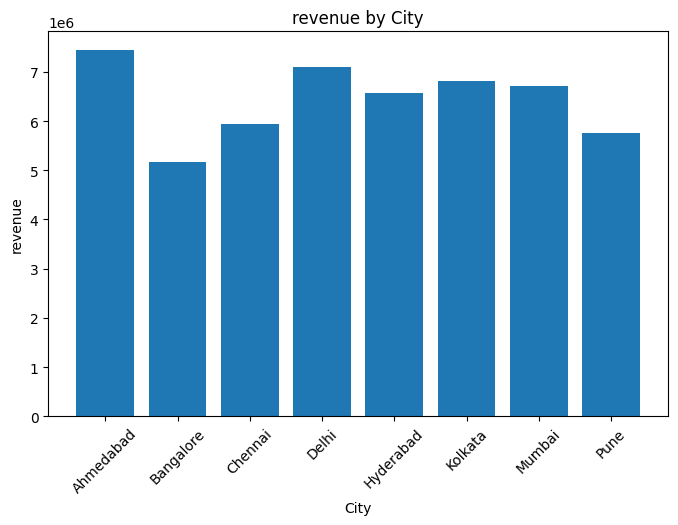

In [ ]:
city_revenue = df.groupby("City")["revenue"].sum()

plt.figure(figsize=(8,5))
plt.bar(city_revenue.index, city_revenue.values)
plt.title("revenue by City")
plt.xlabel("City")
plt.ylabel("revenue")
plt.xticks(rotation=45)

plt.show()

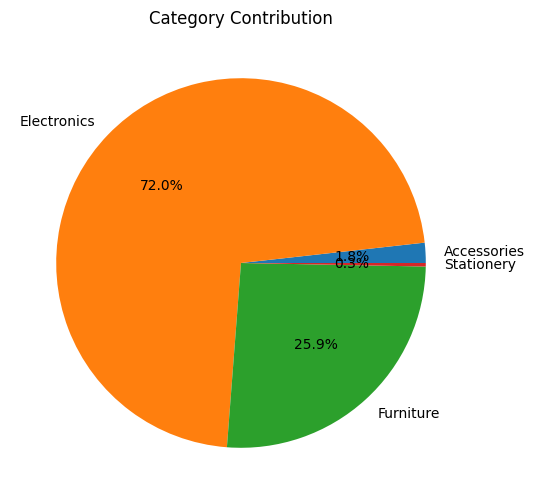

In [ ]:
category_revenue = df.groupby("Category")["revenue"].sum()

plt.figure(figsize=(6,6))
plt.pie(category_revenue.values,
        labels=category_revenue.index,
        autopct="%1.1f%%")

plt.title("Category Contribution")
plt.show()

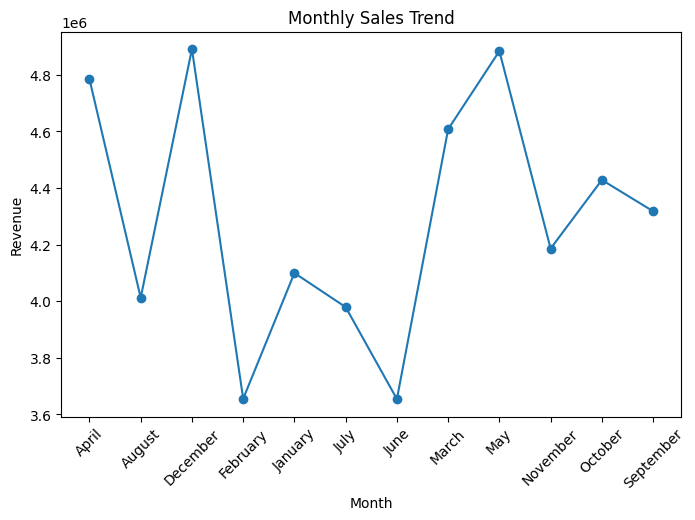

In [ ]:
monthly_sales = df.groupby(df["Date"].dt.strftime("%B"))["revenue"].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()